In [379]:
import numpy as np
from tqdm import tqdm
import math

def transformMatrix(A):
    return np.vstack([np.outer(r, r).flatten() for r in A])

matrix_nullSpaceSolution = {}

def streaming_caratheodory(P, w, d):

    n = len(P)
    selected_points = P[:d+1]
    selected_weights = w[:d+1]
    
    for i in tqdm(range(d+1, n)):

        selected_points = np.vstack((selected_points, P[i]))
        selected_weights = np.append(selected_weights, w[i])
        w1=selected_weights.sum()
        selected_weights = selected_weights / w1
        # print("Rank in streaming caratheodory", d)
        # Apply Caratheodory's theorem to reduce the set to d+1 points
        selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights), P.shape[1])
        selected_weights = selected_weights* w1
    selected_points, selected_weights = caratheodory_debug(np.array(selected_points), np.array(selected_weights), d+1)
    return selected_points, selected_weights

def findNullSpace(A, eps=1e-10):
    B = A.flatten()
    if tuple(B) in matrix_nullSpaceSolution:
        return matrix_nullSpaceSolution[tuple(B)]

    U, S, Vt = np.linalg.svd(A)

    # Null space: all vectors in Vt corresponding to 0 singular values
    null_space = Vt.T[:, np.where(S <= eps)[0]]

    if null_space.shape[1] == 0:
        # You can raise or return a fallback vector
        raise ValueError("Null space is empty — matrix has full row rank.")

    non_trivial_solution = null_space[:, 0]
    matrix_nullSpaceSolution[tuple(B)] = non_trivial_solution
    return non_trivial_solution



def caratheodory(P, w, rank):
    # print("Caratheodory")
    # print(P.shape)
    # print("P.shape", P.shape)
    # print("rank", rank)
    assert len(P) == len(w)
    n, d = P.shape
    # d=rank
    if n <= rank + 1:
        return P, w

    weighted_sum = np.dot(w, P)
    M = (P[1:] - P[0]).T
    v = findNullSpace(M)
    v1 = -np.sum(v)
    v = np.insert(v, 0, v1)

    alpha = np.inf
    for i in range(n):
        if v[i] > 0:
            alpha = min(alpha, w[i] / v[i])
    u = w - alpha * v
    u = np.where(u < 0, 0, u)
    S = P[u > 0]
    u = u[u > 0]
    assert np.allclose(np.dot(u, S), weighted_sum)
    
    if len(S) > rank + 1:
        return caratheodory(S, u, rank)
    return S, u

def fast_caratheodory_set(P, w, k, rank):
    n, d = P.shape
    # print(n, d)
    # Step 1: Remove zero-weight points
    # n= len(P)
    mask = w > 0
    P = P[mask]
    w = w[mask]
    
    # Step 2: Base case
    if len(P) <= rank + 1:
        return P, w

    # Step 4: Partition into k clusters
    partitions = []
    weights_partitions = []
    # k=root(e)*d
    k = int(np.ceil(np.sqrt(math.e) * d))
    if k > len(P):
        k = len(P)
        
    chunk_size = int(np.ceil(len(P) / k))
    if chunk_size<=d+1:
        # print("AAA")
        return streaming_caratheodory(P, w, rank)
    
    for i in range(0, len(P), chunk_size):
        partitions.append(P[i:i + chunk_size])
        weights_partitions.append(w[i:i + chunk_size])

    # Step 5-7: Compute weighted means and cluster weights
    means = []
    new_weights = []
    for Pi, wi in zip(partitions, weights_partitions):
        total_w = np.sum(wi)
        mean = np.dot(wi, Pi) / total_w
        means.append(mean)
        new_weights.append(total_w)
    means = np.array(means)
    new_weights = np.array(new_weights)

    # Step 8: Carathéodory   n cluster means

    reduced_means, reduced_weights = caratheodory(means, new_weights, P.shape[1])

    # Step 9-11: Collect and reweight points from chosen clusters
    C = []
    final_weights = []

    for mean_point, weight in zip(reduced_means, reduced_weights):
        idx = np.where(np.all(means == mean_point, axis=1))[0][0]
        Pi = partitions[idx]
        wi = weights_partitions[idx]
        total_w = np.sum(wi)
        for p, wp in zip(Pi, wi):
            C.append(p)
            final_weights.append(weight * wp / total_w)

    C = np.array(C)
    final_weights = np.array(final_weights)

    # Step 12: Recursive call
    return fast_caratheodory_set(C, final_weights, k, rank)




def caratheodory_debug(P, w, rank):
    # print("Caratheodory")
    rank=np.linalg.matrix_rank(P)
    print(P.shape)
    print("P.shape", P.shape)
    print("rank", rank)
    print(np.linalg.matrix_rank(P))
    assert len(P) == len(w)
    n, d = P.shape
    # d=rank
    if n <= rank + 1:
        return P, w

    weighted_sum = np.dot(w, P)
    M = (P[1:] - P[0]).T
    v = findNullSpace(M)
    v1 = -np.sum(v)
    v = np.insert(v, 0, v1)

    alpha = np.inf
    for i in range(n):
        if v[i] > 0:
            alpha = min(alpha, w[i] / v[i])
    u = w - alpha * v
    u = np.where(u < 0, 0, u)
    S = P[u > 0]
    u = u[u > 0]
    assert np.allclose(np.dot(u, S), weighted_sum)
    
    if len(S) > rank + 1:
        return caratheodory(S, u, rank)
    return S, u





In [380]:
import pandas as pd

df= pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False, na_values=["nan", "?"])
df = df.dropna()
df.head(4)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0


In [381]:
# drop Date and Time
df = df.drop(columns=["Date", "Time"])
# choose Global intensity as y and others as X and create matrix X and y
y = df["Global_intensity"].values
X = df.drop(columns=["Global_intensity"]).values


In [ ]:
import numpy as np
X=np.array(X)
y=np.array(y)
# split into 70:30 ratio

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# print(x_train.shape)

In [387]:
def transformMatrix(A):
    return np.vstack([np.outer(r, r).flatten() for r in A])

In [388]:
import numpy as np

# Make a matrix of the type [X y \n sqrt(lambda)*I 0]
def makeMatrix(X, y, lmbda):
    n = X.shape[0]  # Number of samples
    d = X.shape[1]  # Number of features
    
    # Initialize the matrix A
    A = np.zeros((n + d, d + 1))
    
    # Fill the top part with X and y
    A[:n, :d] = X
    A[:n, d] = y
    
    # Add the regularization term (sqrt(lambda) * I)
    A[n:, :d] = np.sqrt(lmbda) * np.eye(d)
    
    return A

# Example usage
# X = np.random.rand(20, 3)  # Example feature matrix
# y = np.random.rand(20)      # Example target vector
A = makeMatrix(X, y, 0.1)
print(A)

[[  4.216        0.418      234.84       ...   1.          17.
   18.4       ]
 [  5.36         0.436      233.63       ...   1.          16.
   23.        ]
 [  5.374        0.498      233.29       ...   2.          17.
   23.        ]
 ...
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.31622777   0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.31622777
    0.        ]]


In [390]:
import numpy as np




def pca_important_directions(X, threshold=0.99996506):
    X_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)

    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    print("Eigenvalues:", eigenvalues)
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    cumulative_variance = np.cumsum(explained_variance_ratio)
    num_components = np.argmax(cumulative_variance >= threshold) + 1
    return num_components, cumulative_variance

# Example usage:
num_directions, cum_var = pca_important_directions(A)
print("Number of important directions:", num_directions)
print("Cumulative variance explained:", cum_var)


Eigenvalues: [8.61242920e+01 4.13166750e+01 3.34381417e+01 9.28250871e+00
 4.31634417e+00 1.20587713e-02 1.51404650e-03]
Number of important directions: 6
Cumulative variance explained: [0.4935729  0.73035616 0.92198805 0.97518552 0.99992222 0.99999132
 1.        ]


In [391]:
import numpy as np

print(A.shape)
# Step 1: Compute A^T A
ATA = A.T @ A
print(ATA.shape)
# Step 2: Compute eigenvalues
eigenvalues = np.linalg.eigvals(ATA)

print("Eigenvalues of A^T A:", eigenvalues)


(2049286, 7)
(7, 7)
Eigenvalues of A^T A: [1.19024221e+11 1.74855718e+08 8.41236334e+07 6.85026103e+07
 9.48194053e+06 3.41394594e+03 2.47469797e+04]


In [392]:
# # run truncatr SVD on A

def truncated_svd(A, k):
    # Compute the SVD of A
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    
    # Keep only the top k singular values and corresponding vectors
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    
    return U_k, S_k, Vt_k

U1, S1, V1=truncated_svd(A, 20)
# print(U1)

In [393]:
A.shape


(2049286, 7)

In [415]:
n_non_regularization_points = []

for lambda_ in [ 1_00_000, 79437, 50_000,  10_000,1_000,  100, 10, 1]:
    A = makeMatrix(X, y, lambda_)
    # normalize the matrix A
    A = A / 50
    M1=transformMatrix(A)
    u1=np.ones(M1.shape[0])/len(M1)
    d=M1.shape[1]

    print(d)
    k=M1.shape[0]//(d+1)**0.5
    print(k)
    #   chunk_size = int(np.ceil(len(P) / k))

    # def fast_caratheodory_set(P, w, k):
    # def Fast_Caratheodory(P,u,coreset_size, dtype = 'float64'):
    # c, w=Fast_Caratheodory(M1, u1, d*(d+1)/2+1, dtype = 'float64')

    # def Caratheodory(P, u, dtype='float64'):
    # calculate the rank of the matrix M1
    rank = np.linalg.matrix_rank(M1)
    print("Rank of M1:", rank)


    c, u= fast_caratheodory_set(M1, u1, M1.shape[1]+1, rank)
    print(c)
    # count the number of regularization points in the coreset
    num_regularization_points = np.count_nonzero(c[:, -1])
    print("Number of regularization points in the coreset:", num_regularization_points)
    n_non_regularization_points.append(num_regularization_points)
# print("Caratheodory weights:")
# print(w)
# print("Caratheodory weights sum:")
# print(np.sum(w)) 
# print("Caratheodory weights non-zero:")
# print(np.count_nonzero(w))

49
289812.0
Rank of M1: 28


100%|██████████| 3815/3815 [00:00<00:00, 4094.84it/s]


(50, 49)
P.shape (50, 49)
rank 28
28
[[9.16997760e-03 3.83040000e-04 4.56507072e-01 ... 0.00000000e+00
  1.48320000e-01 1.69744000e-01]
 [1.60782400e-04 9.58608000e-05 6.09172560e-02 ... 0.00000000e+00
  0.00000000e+00 3.60000000e-03]
 [1.88348176e-02 1.25162880e-03 6.41844032e-01 ... 3.24000000e-01
  2.16000000e-01 3.60000000e-01]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
Number of regularization points in the coreset: 24
49
289812.0
Rank of M1: 28


100%|██████████| 3815/3815 [00:01<00:00, 3199.64it/s]


(50, 49)
P.shape (50, 49)
rank 28
28
[[1.01284096e-02 4.58918400e-04 4.75121440e-01 ... 4.65920000e-01
  1.52320000e-01 2.00704000e-01]
 [1.33541136e-02 1.89518400e-04 5.42947104e-01 ... 7.08480000e-01
  1.67280000e-01 2.42064000e-01]
 [7.20461440e-03 0.00000000e+00 4.03943920e-01 ... 2.69360000e-01
  0.00000000e+00 1.32496000e-01]
 ...
 [3.17748000e+01 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
Number of regularization points in the coreset: 26
49
289812.0
Rank of M1: 28


...

(50, 49)
P.shape (50, 49)
rank 28
28
[[5.07513760e-03 2.47915200e-04 3.40954640e-01 ... 1.14000000e-01
  1.02000000e-01 9.00000000e-02]
 [4.02971040e-03 8.63328000e-05 3.02304456e-01 ... 5.28000000e-03
  0.00000000e+00 6.96960000e-02]
 [2.31938560e-03 1.04025600e-04 2.30339648e-01 ... 1.48000000e-01
  0.00000000e+00 4.00000000e-02]
 ...
 [6.53510560e-03 1.19643200e-04 3.83941496e-01 ... 2.58400000e-01
  1.22400000e-01 1.15600000e-01]
 [6.36165760e-03 3.95609600e-04 3.81188992e-01 ... 2.11200000e-01
  1.26720000e-01 1.23904000e-01]
 [6.78316960e-03 4.21683200e-04 3.90271096e-01 ... 2.43600000e-01
  1.25280000e-01 1.21104000e-01]]
Number of regularization points in the coreset: 29
49
289812.0
Rank of M1: 28


100%|██████████| 3847/3847 [00:01<00:00, 2847.36it/s]


(50, 49)
P.shape (50, 49)
rank 28
28
[[2.16678400e-02 1.76640000e-04 6.79563520e-01 ... 4.57920000e-01
  2.16240000e-01 4.04496000e-01]
 [1.11851776e-02 0.00000000e+00 4.93687680e-01 ... 9.04000000e-03
  1.53680000e-01 2.04304000e-01]
 [6.60643840e-03 6.79500800e-04 3.88973568e-01 ... 0.00000000e+00
  1.15600000e-01 1.15600000e-01]
 ...
 [6.02176000e-03 4.46976000e-04 3.61538400e-01 ... 1.37600000e-02
  1.16960000e-01 1.18336000e-01]
 [1.72723360e-03 2.95907200e-04 1.92356304e-01 ... 0.00000000e+00
  9.72000000e-02 3.24000000e-02]
 [6.90638400e-04 3.88944000e-05 1.22428008e-01 ... 0.00000000e+00
  4.03200000e-02 1.25440000e-02]]
Number of regularization points in the coreset: 29
49
289812.0
Rank of M1: 28


100%|██████████| 3853/3853 [00:01<00:00, 3006.08it/s]


(50, 49)
P.shape (50, 49)
rank 28
28
[[8.53036960e-03 1.32998400e-04 4.35071016e-01 ... 5.64480000e-01
  0.00000000e+00 1.53664000e-01]
 [9.71407360e-03 7.09632000e-04 4.58008320e-01 ... 1.61120000e-01
  1.35680000e-01 1.79776000e-01]
 [1.01687056e-02 7.54283200e-04 4.64670720e-01 ... 0.00000000e+00
  0.00000000e+00 1.93600000e-01]
 ...
 [4.87204000e-03 8.65520000e-05 3.29567680e-01 ... 0.00000000e+00
  9.92800000e-02 8.52640000e-02]
 [2.02860160e-03 5.94528000e-04 2.14066112e-01 ... 0.00000000e+00
  7.34400000e-02 4.16160000e-02]
 [5.04668160e-03 3.06892800e-04 3.41730816e-01 ... 0.00000000e+00
  0.00000000e+00 8.76160000e-02]]
Number of regularization points in the coreset: 29


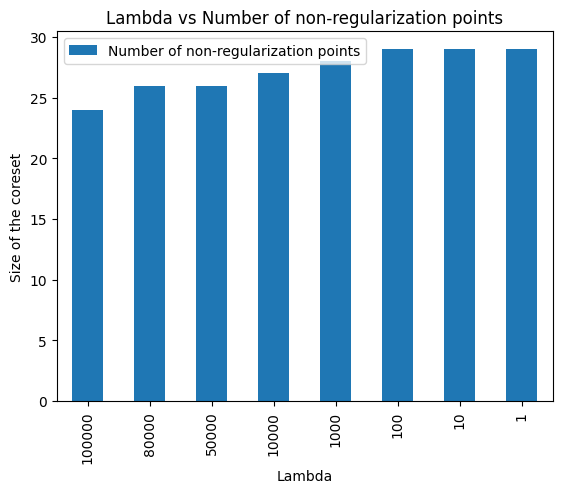

        Number of non-regularization points
Lambda                                     
100000                                   24
80000                                    26
50000                                    26
10000                                    27
1000                                     28
100                                      29
10                                       29
1                                        29


In [417]:
# create a table for Lambda vs the number of non-regularization points in the coreset
import pandas as pd
import matplotlib.pyplot as plt

lambdas= [ 1_00_000,80000,50_000,  10_000,1_000,  100, 10, 1]
df = pd.DataFrame({'Lambda': lambdas, 'Number of non-regularization points': n_non_regularization_points})
df = df.set_index('Lambda')
df.plot(kind='bar')
plt.xlabel('Lambda')
plt.ylabel('Size of the coreset')
plt.title('Lambda vs Number of non-regularization points')
plt.show()
print(df)
